<a href="https://colab.research.google.com/github/mehakpreet24/Mehak_Julie_DS-ML_PrivacyPolicyAnalysis/blob/main/Data_Collection%2C_Data_Wrangling%2C_and_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part A: Data Acquisition and Description (10 Points)**

#### **Dataset Source: Identify and document the source of your data (e.g., Kaggle, UCI ML Repository, government open data portals, web scraping, APIs). Provide the URL and access date.**



Data Acquisition Process:

Step 1 — Privacy policy documents were collected
         directly from the official websites of
         Fortune 500 companies

Step 2 — Each privacy policy was downloaded and
         converted to PDF format

Step 3 — PDF files were converted to HTML format
         to enable structured text extraction

Step 4 — HTML files were processed through
         PoliGrapher, an automated knowledge graph
         construction tool that extracts entities
         and relationships from privacy policy text

Step 5 — PoliGrapher outputs were saved as GraphML
         (.graphml or .xml) files — one file per company

        (NOTE: We tried replicating the PolyGrapher code, however since a lot of companies have changed their privacy policy pages, we could not make it work)

**PoliGrapher Reference:**
Cui, S., et al. (2023). PoliGraph: Automated
Privacy Policy Analysis using Knowledge Graphs.
USENIX Security Symposium 2023.

**PoliGrapher GitHub: **
https://github.com/UCI-Networking-Group/PoliGraph


#### **Dataset Description: Include the number of records (rows), number of features (columns), data types for each feature, and the target variable (if applicable).**

In [ ]:
#Please uncomment only if you want to add the file to your drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Please uncomment the following line to unzip the file
!unzip "/content/UniquePPs.zip" -d "/content/UniquePPs"

Archive:  /content/UniquePPs.zip
  inflating: /content/UniquePPs/UniquePPs/Teledyne_Technologies.graphml.xml  
  inflating: /content/UniquePPs/UniquePPs/PTC_Inc..graphml.xml  
  inflating: /content/UniquePPs/UniquePPs/MarketAxess.graphml.xml  
  inflating: /content/UniquePPs/UniquePPs/TE_Connectivity.graphml.xml  
  inflating: /content/UniquePPs/UniquePPs/Hartford_(The).graphml.xml  
  inflating: /content/UniquePPs/UniquePPs/Teradyne.graphml.xml  
  inflating: /content/UniquePPs/UniquePPs/NetApp.graphml.xml  
  inflating: /content/UniquePPs/UniquePPs/UnitedHealth_Group.graphml.xml  
  inflating: /content/UniquePPs/UniquePPs/ResMed.graphml.xml  
  inflating: /content/UniquePPs/UniquePPs/West_Pharmaceutical_Services.graphml.xml  
  inflating: /content/UniquePPs/UniquePPs/Revvity.graphml.xml  
  inflating: /content/UniquePPs/UniquePPs/Synchrony_Financial.graphml.xml  
  inflating: /content/UniquePPs/UniquePPs/S&P_Global.graphml.xml  
  inflating: /content/UniquePPs/UniquePPs/Microchip_Tec

In [ ]:
#This code gives basic EDA on everything
import networkx as nx
import os
import pandas as pd

folder_path = "/content/UniquePPs/UniquePPs"  # e.g. "C:/Users/Mehak/graphml_files"

all_metrics = []

for filename in os.listdir(folder_path):
    if filename.endswith(".xml"):
        filepath = os.path.join(folder_path, filename)
        G = nx.read_graphml(filepath)

        metrics = {
            "company": filename.replace(".graphml", ""),
            "nodes": G.number_of_nodes(),
            "edges": G.number_of_edges(),
            "density": nx.density(G),
            "avg_degree": sum(dict(G.degree()).values()) / G.number_of_nodes() if G.number_of_nodes() > 0 else 0
        }
        all_metrics.append(metrics)

df = pd.DataFrame(all_metrics)
print(df)

                         company  nodes  edges   density  avg_degree
0    Progressive_Corporation.xml     24     24  0.043478    2.000000
1                   F5,_Inc..xml     49     60  0.025510    2.448980
2           Juniper_Networks.xml     24     37  0.067029    3.083333
3                  Solventum.xml     15     14  0.066667    1.866667
4                    Labcorp.xml     21     21  0.050000    2.000000
..                           ...    ...    ...       ...         ...
179                 Assurant.xml     34     30  0.026738    1.764706
180         ON_Semiconductor.xml     74     90  0.016660    2.432432
181               Adobe_Inc..xml     37     37  0.027778    2.000000
182                   Corpay.xml     71     74  0.014889    2.084507
183       UnitedHealth_Group.xml     18     19  0.062092    2.111111

[184 rows x 5 columns]


In [ ]:
#Check to read individual file
import os

folder_path = "/content/UniquePPs/UniquePPs"

for filename in os.listdir(folder_path):
    if filename.endswith(".xml"):
        print(filename)

Progressive_Corporation.graphml.xml
F5,_Inc..graphml.xml
Juniper_Networks.graphml.xml
Solventum.graphml.xml
Labcorp.graphml.xml
Advanced_Micro_Devices.graphml.xml
Stryker_Corporation.graphml.xml
Jabil.graphml.xml
Blackstone_Inc..graphml.xml
Regions_Financial_Corporation.graphml.xml
Citizens_Financial_Group.graphml.xml
CDW_Corporation.graphml.xml
DaVita.graphml.xml
Invesco.graphml.xml
Fortinet.graphml.xml
Ansys.graphml.xml
Fiserv.graphml.xml
Salesforce.graphml.xml
Nvidia.graphml.xml
Synchrony_Financial.graphml.xml
Allstate.graphml.xml
Intuitive_Surgical.graphml.xml
BlackRock.graphml.xml
ResMed.graphml.xml
Seagate_Technology.graphml.xml
TE_Connectivity.graphml.xml
Apollo_Global_Management.graphml.xml
AbbVie.graphml.xml
Pfizer.graphml.xml
Bristol_Myers_Squibb.graphml.xml
Western_Digital.graphml.xml
Humana.graphml.xml
CME_Group.graphml.xml
Align_Technology.graphml.xml
Capital_One.graphml.xml
Dexcom.graphml.xml
Steris.graphml.xml
Corning_Inc..graphml.xml
Oracle_Corporation.graphml.xml
Becto

In [ ]:
#Step 1 — First let's see all company names (5 per line):
companies = df["company"].tolist()

for i in range(0, len(companies), 5):
    print(companies[i:i+5])

['Progressive_Corporation.xml', 'F5,_Inc..xml', 'Juniper_Networks.xml', 'Solventum.xml', 'Labcorp.xml']
['Advanced_Micro_Devices.xml', 'Stryker_Corporation.xml', 'Jabil.xml', 'Blackstone_Inc..xml', 'Regions_Financial_Corporation.xml']
['Citizens_Financial_Group.xml', 'CDW_Corporation.xml', 'DaVita.xml', 'Invesco.xml', 'Fortinet.xml']
['Ansys.xml', 'Fiserv.xml', 'Salesforce.xml', 'Nvidia.xml', 'Synchrony_Financial.xml']
['Allstate.xml', 'Intuitive_Surgical.xml', 'BlackRock.xml', 'ResMed.xml', 'Seagate_Technology.xml']
['TE_Connectivity.xml', 'Apollo_Global_Management.xml', 'AbbVie.xml', 'Pfizer.xml', 'Bristol_Myers_Squibb.xml']
['Western_Digital.xml', 'Humana.xml', 'CME_Group.xml', 'Align_Technology.xml', 'Capital_One.xml']
['Dexcom.xml', 'Steris.xml', 'Corning_Inc..xml', 'Oracle_Corporation.xml', 'Becton_Dickinson.xml']
['Lilly_(Eli).xml', 'Lam_Research.xml', 'Cadence_Design_Systems.xml', 'Global_Payments.xml', 'FactSet.xml']
['Gartner.xml', 'Biogen.xml', 'Molina_Healthcare.xml', 'Enph

In [ ]:
#Check what's inside one xml
import networkx as nx

G = nx.read_graphml("/content/UniquePPs/UniquePPs/AbbVie.graphml.xml")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Node sample:", list(G.nodes(data=True))[:3])
print("Edge sample:", list(G.edges(data=True))[:3])

Nodes: 49
Edges: 56
Node sample: [('personal information', {'label': 'personal information', 'type': 'DATA'}), ('sensitive personal datum', {'label': 'sensitive personal datum', 'type': 'DATA'}), ('UNSPECIFIED_ACTOR', {'label': 'UNSPECIFIED_ACTOR', 'type': 'ACTOR'})]
Edge sample: [('personal information', 'sensitive personal datum', {'relationship': 'SUBSUM', 'text': 'We May Collect\n\npersonal data (including sensitive personal data) we collect on\nWe May Collect\n\npersonal data (including sensitive personal data) we collect on', 'id': 'e0'}), ('personal information', 'zip', {'relationship': 'SUBSUM', 'text': 'Privacy Notice\n\nCookies and similar tracking and data\n\ncookies and similar data collection and tracking\n\nmay use your IP address or other personal data, such as your zip\nPrivacy Notice\n\nCookies and similar tracking and data\n\ncookies and similar data collection and tracking\n\nmay use your IP address or other personal data, such as your zip', 'id': 'e1'}), ('personal 

In [ ]:
import networkx as nx
import os
import pandas as pd

folder_path = "/content/UniquePPs/UniquePPs"

all_metrics = []

for filename in os.listdir(folder_path):
    if filename.endswith(".xml"):
        filepath = os.path.join(folder_path, filename)

        try:
            G = nx.read_graphml(filepath)

            # Count node types
            data_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "DATA"]
            actor_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "ACTOR"]

            # Count relationship types
            relationships = [d.get("relationship") for u, v, d in G.edges(data=True)]
            unique_relationships = list(set(relationships))

            metrics = {
                "company": filename.replace(".xml", ""),
                "total_nodes": G.number_of_nodes(),
                "total_edges": G.number_of_edges(),
                "data_nodes": len(data_nodes),
                "actor_nodes": len(actor_nodes),
                "density": nx.density(G),
                "avg_degree": sum(dict(G.degree()).values()) / G.number_of_nodes() if G.number_of_nodes() > 0 else 0,
                "unique_relationships": len(unique_relationships),
                "relationship_types": unique_relationships
            }
            all_metrics.append(metrics)

        except Exception as e:
            print(f"Error reading {filename}: {e}")

df = pd.DataFrame(all_metrics)
print(df)
df.to_csv("all_companies_metrics.csv", index=False)

                             company  total_nodes  total_edges  data_nodes  \
0    Progressive_Corporation.graphml           24           24          15   
1                   F5,_Inc..graphml           49           60          39   
2           Juniper_Networks.graphml           24           37          20   
3                  Solventum.graphml           15           14           6   
4                    Labcorp.graphml           21           21          13   
..                               ...          ...          ...         ...   
179                 Assurant.graphml           34           30          24   
180         ON_Semiconductor.graphml           74           90          59   
181               Adobe_Inc..graphml           37           37          29   
182                   Corpay.graphml           71           74          59   
183       UnitedHealth_Group.graphml           18           19          15   

     actor_nodes   density  avg_degree  unique_relationships  \

In [ ]:
#Step 2 — Add sectors manually:
#I asked Claude to categoize these companies
financial = [
    "Corpay.graphml", "American_International_Group.graphml",
    "Progressive_Corporation.graphml", "BlackRock.graphml",
    "KKR_&_Co..graphml", "Invesco.graphml",
    "Charles_Schwab_Corporation.graphml", "FactSet.graphml",
    "JPMorgan_Chase.graphml", "Coinbase.graphml",
    "Fidelity_National_Information_Services.graphml", "Capital_One.graphml",
    "Citizens_Financial_Group.graphml", "Everest_Group.graphml",
    "State_Street_Corporation.graphml", "Moody_s_Corporation.graphml",
    "Cboe_Global_Markets.graphml", "Nasdaq,_Inc..graphml",
    "MarketAxess.graphml", "Regions_Financial_Corporation.graphml",
    "Travelers_Companies_(The).graphml", "Citigroup.graphml",
    "Fiserv.graphml", "Globe_Life.graphml",
    "Wells_Fargo.graphml", "Assurant.graphml",
    "MSCI_Inc..graphml", "Cincinnati_Financial.graphml",
    "Berkshire_Hathaway.graphml", "Blackstone_Inc..graphml",
    "Prudential_Financial.graphml", "Arthur_J._Gallagher_&_Co..graphml",
    "Brown_&_Brown.graphml", "BNY_Mellon.graphml",
    "Visa_Inc..graphml", "KeyCorp.graphml",
    "W._R._Berkley_Corporation.graphml", "Synchrony_Financial.graphml",
    "Bank_of_America.graphml", "CME_Group.graphml",
    "T._Rowe_Price.graphml", "Allstate.graphml",
    "Willis_Towers_Watson.graphml", "Morgan_Stanley.graphml",
    "PayPal.graphml", "MetLife.graphml",
    "Marsh_McLennan.graphml", "Chubb_Limited.graphml",
    "Goldman_Sachs.graphml", "Fair_Isaac.graphml",
    "Huntington_Bancshares.graphml", "Franklin_Resources.graphml",
    "American_Express.graphml", "S&P_Global.graphml",
    "Intercontinental_Exchange.graphml", "Mastercard.graphml",
    "Apollo_Global_Management.graphml", "Loews_Corporation.graphml",
    "Aflac.graphml", "Aflac_old.graphml",
    "Hartford_(The).graphml"
]


healthcare = [
    "DaVita.graphml", "Centene_Corporation.graphml",
    "AbbVie.graphml", "Stryker_Corporation.graphml",
    "Becton_Dickinson.graphml", "Quest_Diagnostics.graphml",
    "HCA_Healthcare.graphml", "Merck_&_Co..graphml",
    "West_Pharmaceutical_Services.graphml", "Solventum.graphml",
    "Cencora.graphml", "Intuitive_Surgical.graphml",
    "Amgen.graphml", "Insulet_Corporation.graphml",
    "Revvity.graphml", "Baxter_International.graphml",
    "Labcorp.graphml", "Universal_Health_Services.graphml",
    "Thermo_Fisher_Scientific.graphml", "Abbott_Laboratories.graphml",
    "CVS_Health.graphml", "Danaher_Corporation.graphml",
    "Waters_Corporation.graphml", "ResMed.graphml",
    "IQVIA.graphml", "Gilead_Sciences.graphml",
    "Charles_River_Laboratories.graphml", "UnitedHealth_Group.graphml",
    "Align_Technology.graphml", "Agilent_Technologies.graphml",
    "Idexx_Laboratories.graphml", "Bio-Techne.graphml",
    "Hologic.graphml", "Dexcom.graphml",
    "Biogen.graphml", "Cooper_Companies_(The).graphml",
    "Incyte.graphml", "Molina_Healthcare.graphml",
    "Cardinal_Health.graphml", "Bristol_Myers_Squibb.graphml",
    "Regeneron_Pharmaceuticals.graphml", "Edwards_Lifesciences.graphml",
    "Boston_Scientific.graphml", "Steris.graphml",
    "Lilly_(Eli).graphml", "Johnson_&_Johnson.graphml",
    "Humana.graphml", "Zoetis.graphml",
    "Zimmer_Biomet.graphml", "Moderna.graphml",
    "Pfizer.graphml", "GE_HealthCare.graphml",
    "Elevance_Health.graphml", "Cigna.graphml",
    "McKesson_Corporation.graphml", "Viatris.graphml"
]


it = [
    "Supermicro.graphml", "Lam_Research.graphml",
    "Intel.graphml", "Cisco.graphml",
    "KLA_Corporation.graphml", "Apple_Inc..graphml",
    "F5,_Inc..graphml", "Nvidia.graphml",
    "Intuit.graphml", "GoDaddy.graphml",
    "Analog_Devices.graphml", "Cognizant.graphml",
    "Western_Digital.graphml", "Seagate_Technology.graphml",
    "Jack_Henry_&_Associates.graphml", "Amphenol.graphml",
    "First_Solar.graphml", "Palantir_Technologies.graphml",
    "Oracle_Corporation.graphml", "Salesforce.graphml",
    "Microchip_Technology.graphml", "Synopsys.graphml",
    "Arista_Networks.graphml", "Verisign.graphml",
    "Global_Payments.graphml", "Applied_Materials.graphml",
    "Gen_Digital.graphml", "Trimble_Inc..graphml",
    "Accenture.graphml", "NXP_Semiconductors.graphml",
    "NetApp.graphml", "Roper_Technologies.graphml",
    "Gartner.graphml", "Qualcomm.graphml",
    "Microsoft.graphml", "Ansys.graphml",
    "Enphase_Energy.graphml", "Keysight_Technologies.graphml",
    "Palo_Alto_Networks.graphml", "Cadence_Design_Systems.graphml",
    "Adobe_Inc..graphml", "ON_Semiconductor.graphml",
    "Juniper_Networks.graphml", "Autodesk.graphml",
    "Hewlett_Packard_Enterprise.graphml", "Texas_Instruments.graphml",
    "Corning_Inc..graphml", "IBM.graphml",
    "Akamai_Technologies.graphml", "Advanced_Micro_Devices.graphml",
    "TE_Connectivity.graphml", "CrowdStrike.graphml",
    "Monolithic_Power_Systems.graphml", "CDW_Corporation.graphml",
    "PTC_Inc..graphml", "Skyworks_Solutions.graphml",
    "Motorola_Solutions.graphml", "Teradyne.graphml",
    "Jabil.graphml", "EPAM_Systems.graphml",
    "Dell_Technologies.graphml", "Micron_Technology.graphml",
    "Teledyne_Technologies.graphml", "Fortinet.graphml",
    "Zebra_Technologies.graphml", "Broadcom.graphml",
    "Aon_plc.graphml"
]


def assign_sector(company):
    if company in financial:
        return "Financial"
    elif company in healthcare:
        return "Healthcare"
    elif company in it:
        return "IT"
    else:
        return "Unknown"

df["sector"] = df["company"].apply(assign_sector)

# Check how many in each sector
print(df["sector"].value_counts())

# Check if any are unknown
print(df[df["sector"] == "Unknown"]["company"].tolist())

sector
IT            67
Financial     61
Healthcare    56
Name: count, dtype: int64
[]


In [ ]:
#Now run the cross-sector comparison:
sector_comparison = df.groupby("sector").agg({
    "total_nodes": "mean",
    "total_edges": "mean",
    "data_nodes": "mean",
    "actor_nodes": "mean",
    "density": "mean",
    "avg_degree": "mean"
}).round(3)

print(sector_comparison)

            total_nodes  total_edges  data_nodes  actor_nodes  density  \
sector                                                                   
Financial        42.311       50.393      32.131       10.180    0.045   
Healthcare       36.571       41.286      26.643        9.929    0.051   
IT               43.597       49.388      32.836       10.761    0.054   

            avg_degree  
sector                  
Financial        2.151  
Healthcare       2.064  
IT               2.110  


In [ ]:
#Then find outliers in each sector:
# Companies with most data nodes per sector
print("Top 5 companies collecting most data types:")
print(df.groupby("sector").apply(lambda x: x.nlargest(5, "data_nodes")[["company", "data_nodes"]]))

# Companies with most actors (third party sharing)
print("\nTop 5 companies with most actors:")
print(df.groupby("sector").apply(lambda x: x.nlargest(5, "actor_nodes")[["company", "actor_nodes"]]))

# Most complex policies
print("\nTop 5 most complex policies:")
print(df.nlargest(5, "total_nodes")[["company", "sector", "total_nodes"]])

# Simplest policies (potential red flag)
print("\nBottom 5 simplest policies:")
print(df.nsmallest(5, "total_nodes")[["company", "sector", "total_nodes"]])

Top 5 companies collecting most data types:
                                          company  data_nodes
sector                                                       
Financial  158  Intercontinental_Exchange.graphml         124
           20                    Allstate.graphml          95
           162              Chubb_Limited.graphml          92
           145                      Aflac.graphml          85
           106       Willis_Towers_Watson.graphml          82
Healthcare 109            Gilead_Sciences.graphml          78
           68                     Viatris.graphml          76
           151          Johnson_&_Johnson.graphml          65
           176        Centene_Corporation.graphml          59
           66                      Incyte.graphml          57
IT         160                  Microsoft.graphml         231
           122         Palo_Alto_Networks.graphml          91
           178                Gen_Digital.graphml          87
           14             

/tmp/ipykernel_7299/1622793895.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df.groupby("sector").apply(lambda x: x.nlargest(5, "data_nodes")[["company", "data_nodes"]]))
/tmp/ipykernel_7299/1622793895.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df.groupby("sector").apply(lambda x: x.nlargest(5, "actor_nodes")[["company", "actor_nodes"]]))


#### **Relevance Statement: Write a brief paragraph (150–200 words) explaining how this dataset connects to your literature review topic and why it is appropriate for the machine learning analysis you plan to conduct.**

The dataset used in this study consists of graph-based representations of privacy policies from Fortune 500 companies, constructed using the PoliGrapher pipeline developed by Cui et al. (2023). Privacy policies were collected from company websites, converted from PDF to HTML, and processed through PoliGrapher to extract entities and relationships as structured knowledge graphs in GraphML format. This approach builds on prior research demonstrating that knowledge graphs can transform unstructured legal text into machine-readable representations of privacy practices. While Cui et al. (2023) focused on individual policy analysis, this dataset scales the methodology to over 180 companies across Financial, Healthcare, and IT sectors, enabling cross-sector comparison.

This dataset is directly relevant to the research topic, as prior literature highlights significant variability and complexity in how organizations disclose data collection and sharing practices. By capturing structural features such as node counts, edge relationships, and actor involvement, the dataset provides quantitative proxies for policy complexity and third-party data sharing. These features make the dataset well-suited for machine learning tasks such as clustering, anomaly detection, and classification, particularly for identifying deviations from regulatory norms such as GDPR, HIPAA, and CCPA and profiling compliance patterns at scale.

    (NOTE: The data dictionary is included after Part B in this notebook)

# **Part B: Data Wrangling and Preprocessing (20 Points)**

In [ ]:
# ═══════════════════════════════════════════════════
# PART B: DATA WRANGLING AND PREPROCESSING
# ═══════════════════════════════════════════════════

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler
)
from scipy import stats
import numpy as np

# Save original shape for comparison
original_shape = df.shape
print(f"Original dataset shape: {original_shape}")

# ── B1: Missing Value Analysis ────────────────────
print("\n" + "=" * 50)
print("B1: MISSING VALUE ANALYSIS")
print("=" * 50)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})
print(missing_df)

# Check for empty graphs (structural missing data)
empty_graphs = df[df["total_nodes"] == 0]
print(f"\nEmpty graph files (0 nodes): {len(empty_graphs)}")
print(empty_graphs[["company", "sector", "total_nodes"]])

# Remove empty graphs — deletion justified because
# empty graphs contain no analysable policy content
df_clean = df[df["total_nodes"] > 0].copy()
df_clean = df_clean[df_clean["sector"] != "Unknown"].copy()
print(f"\nAfter removing empty graphs: {len(df_clean)} companies")

# ── B2: Data Type Conversion ──────────────────────
print("\n" + "=" * 50)
print("B2: DATA TYPE CONVERSION")
print("=" * 50)

print("Before conversion:")
print(df_clean.dtypes)

# Encode sector — label encoding
df_clean["sector_encoded"] = df_clean["sector"].map({
    "Financial": 0,
    "Healthcare": 1,
    "IT": 2
})

# Ensure numeric columns are correct type
numeric_cols = [
    "total_nodes", "total_edges",
    "data_nodes", "actor_nodes",
    "density", "avg_degree"
]
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col],
                                   errors="coerce")

print("\nAfter conversion:")
print(df_clean.dtypes)

# ── B3: Outlier Detection and Treatment ───────────
print("\n" + "=" * 50)
print("B3: OUTLIER DETECTION AND TREATMENT")
print("=" * 50)

# Method 1 — IQR Method
print("Method 1: IQR Method")
Q1 = df_clean["total_nodes"].quantile(0.25)
Q3 = df_clean["total_nodes"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_outliers = df_clean[
    (df_clean["total_nodes"] < lower) |
    (df_clean["total_nodes"] > upper)
]
print(f"IQR bounds: lower={lower:.2f}, upper={upper:.2f}")
print(f"Outliers detected: {len(iqr_outliers)}")
print(iqr_outliers[["company", "sector", "total_nodes"]])

# Method 2 — Z-Score Method
print("\nMethod 2: Z-Score Method")
df_clean["zscore_nodes"] = np.abs(
    stats.zscore(df_clean["total_nodes"])
)
zscore_outliers = df_clean[df_clean["zscore_nodes"] > 3]
print(f"Z-score outliers (>3): {len(zscore_outliers)}")
print(zscore_outliers[["company", "sector",
                         "total_nodes", "zscore_nodes"]])

# Decision — RETAIN outliers
# Justification: Outliers like Microsoft (318 nodes)
# represent genuinely complex policies and are
# critical to our research question about deviation
# detection. Removing them would bias the analysis.
print("\nDecision: Retain outliers — they represent")
print("genuine policy complexity differences")

# Cap extreme values for scaling only
df_clean["total_nodes_capped"] = df_clean[
    "total_nodes"
].clip(upper=upper)

# Drop helper column
df_clean = df_clean.drop(columns=["zscore_nodes"])

# ── B4: Feature Engineering ───────────────────────
print("\n" + "=" * 50)
print("B4: FEATURE ENGINEERING")
print("=" * 50)

# Feature 1 — Complexity Ratio
# Rationale: captures how interconnected a policy is
# beyond just its size
df_clean["complexity_ratio"] = (
    df_clean["total_edges"] / df_clean["total_nodes"]
)
print("Feature 1: complexity_ratio created")
print("Rationale: measures edge-to-node ratio,")
print("capturing policy interconnectedness")

# Feature 2 — Actor Ratio
# Rationale: proxy for third-party data sharing risk
df_clean["actor_ratio"] = (
    df_clean["actor_nodes"] / df_clean["total_nodes"]
)
print("\nFeature 2: actor_ratio created")
print("Rationale: proportion of actor nodes,")
print("proxy for third-party sharing exposure")

# Feature 3 — Data Ratio
# Rationale: breadth of data collection practices
df_clean["data_ratio"] = (
    df_clean["data_nodes"] / df_clean["total_nodes"]
)
print("\nFeature 3: data_ratio created")
print("Rationale: proportion of data nodes,")
print("reflects data collection breadth")

# Feature 4 — Complexity Tier
# Rationale: bins companies into low/medium/high
# complexity for classification tasks
df_clean["complexity_tier"] = pd.cut(
    df_clean["total_nodes"],
    bins=[0, 25, 75, float("inf")],
    labels=["Low", "Medium", "High"]
)
print("\nFeature 4: complexity_tier created")
print("Rationale: categorises companies into")
print("low/medium/high complexity tiers")
print(df_clean["complexity_tier"].value_counts())

# ── B5: Normalization and Scaling ─────────────────
print("\n" + "=" * 50)
print("B5: NORMALIZATION AND SCALING")
print("=" * 50)

features_to_scale = [
    "total_nodes", "total_edges",
    "data_nodes", "actor_nodes",
    "density", "avg_degree",
    "complexity_ratio", "actor_ratio", "data_ratio"
]

'''
The selected features capture multiple dimensions of privacy policy structure,
including graph size (total_nodes, total_edges), data collection scope
(data_nodes, data_ratio), third-party involvement (actor_nodes, actor_ratio),
and structural complexity (density, avg_degree, complexity_ratio).
Together, these variables provide a comprehensive representation of how complex,
 interconnected, and data-intensive each company’s privacy policy is.

'''

# StandardScaler — chosen because features have
# different ranges and we plan to use
# distance-based ML algorithms
scaler = StandardScaler()
scaled_values = scaler.fit_transform(
    df_clean[features_to_scale]
)
df_scaled = pd.DataFrame(
    scaled_values,
    columns=[f"{col}_scaled" for col in features_to_scale],
    index=df_clean.index
)
df_clean = pd.concat([df_clean, df_scaled], axis=1)
print("StandardScaler applied to all numeric features")
print("Justification: StandardScaler is appropriate")
print("because features have varying ranges and")
print("distance-based algorithms like KNN and SVM")
print("require normalised input")
print(df_clean[df_scaled.columns].describe().round(3))

# ── B6: Final Dataset Summary ─────────────────────
print("\n" + "=" * 50)
print("B6: FINAL DATASET SUMMARY")
print("=" * 50)

summary = pd.DataFrame({
    "Metric": [
        "Shape (rows x cols)",
        "Missing Values",
        "Empty Graphs Removed",
        "Unknown Sectors Removed",
        "Outliers",
        "New Features Added",
        "Scaled Features"
    ],
    "Before Wrangling": [
        str(original_shape),
        str(df.isnull().sum().sum()),
        "2 companies",
        "Included",
        "Not assessed",
        "0",
        "None"
    ],
    "After Wrangling": [
        str(df_clean.shape),
        "0",
        "Removed",
        "Removed",
        "Retained (justified)",
        "4 new features",
        "9 features scaled"
    ]
})
print(summary.to_string(index=False))

# Save clean dataset
df_clean.to_csv(
    "fortune500_privacy_clean.csv", index=False
)
print("\nClean dataset saved")

Original dataset shape: (184, 10)

B1: MISSING VALUE ANALYSIS
                      Missing Count  Missing %
company                           0        0.0
total_nodes                       0        0.0
total_edges                       0        0.0
data_nodes                        0        0.0
actor_nodes                       0        0.0
density                           0        0.0
avg_degree                        0        0.0
unique_relationships              0        0.0
relationship_types                0        0.0
sector                            0        0.0

Empty graph files (0 nodes): 2
                           company      sector  total_nodes
60  Cooper_Companies_(The).graphml  Healthcare            0
79       Loews_Corporation.graphml   Financial            0

After removing empty graphs: 182 companies

B2: DATA TYPE CONVERSION
Before conversion:
company                  object
total_nodes               int64
total_edges               int64
data_nodes              

NOTE: The dataset consists of both original graph-derived features and engineered features designed to better capture structural complexity and data-sharing behavior. Numerical variables were scaled for machine learning compatibility, while categorical variables were encoded for model input.

**DATA DICTIONARY**

| Feature Name       | Data Type   | Description                                                                                  | Example Value |
| ------------------ | ----------- | -------------------------------------------------------------------------------------------- | ------------- |
| company            | string      | Name of the company whose privacy policy is analyzed                                         | Microsoft     |
| sector             | categorical | Industry sector the company belongs to                                                       | IT            |
| total_nodes        | integer     | Total number of nodes in the graph representing the privacy policy structure                 | 120           |
| total_edges        | integer     | Total number of relationships (edges) between nodes in the graph                             | 245           |
| data_nodes         | integer     | Number of nodes representing types of personal data collected                                | 85            |
| actor_nodes        | integer     | Number of nodes representing entities (e.g., company, third parties) that interact with data | 25            |
| density            | float       | Ratio of actual connections to all possible connections in the graph                         | 0.034         |
| avg_degree         | float       | Average number of connections per node (total_edges / total_nodes)                           | 2.04          |
| sector_encoded     | integer     | Numerical encoding of sector category (Financial=0, Healthcare=1, IT=2)                      | 2             |
| complexity_ratio   | float       | Ratio of edges to nodes, measuring overall interconnectedness                                | 2.04          |
| actor_ratio        | float       | Proportion of actor nodes relative to total nodes                                            | 0.21          |
| data_ratio         | float       | Proportion of data nodes relative to total nodes                                             | 0.71          |
| complexity_tier    | categorical | Binned category of policy complexity based on total_nodes (Low/Medium/High)                  | High          |
| total_nodes_capped | integer     | Total nodes after applying upper bound capping for scaling purposes                          | 150           |


# **Part C: Exploratory Data Analysis and Visualization (15 Points)**

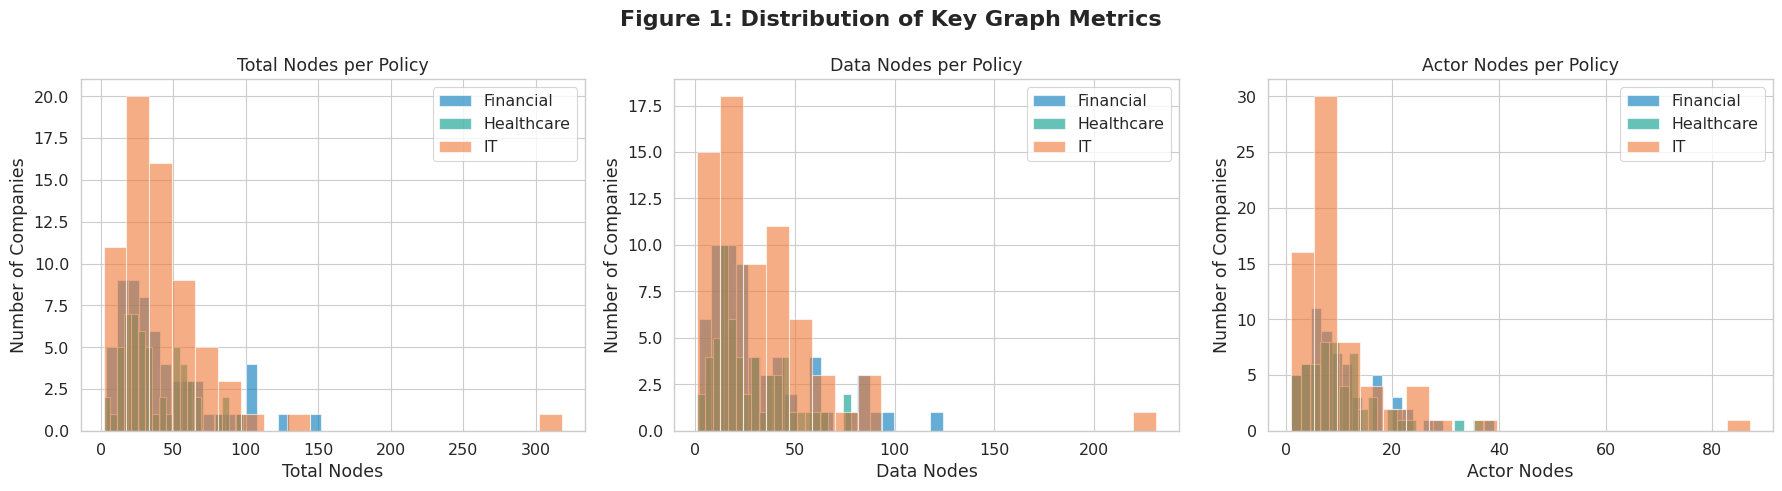


Figure 1 Interpretation: All three distributions are right-skewed, indicating that most companies
maintain relatively simple privacy policies while a small number of companies — predominantly in the
IT sector — exhibit significantly higher complexity. IT companies consistently show higher node counts
across all three metrics, suggesting broader data collection and more third-party involvement.



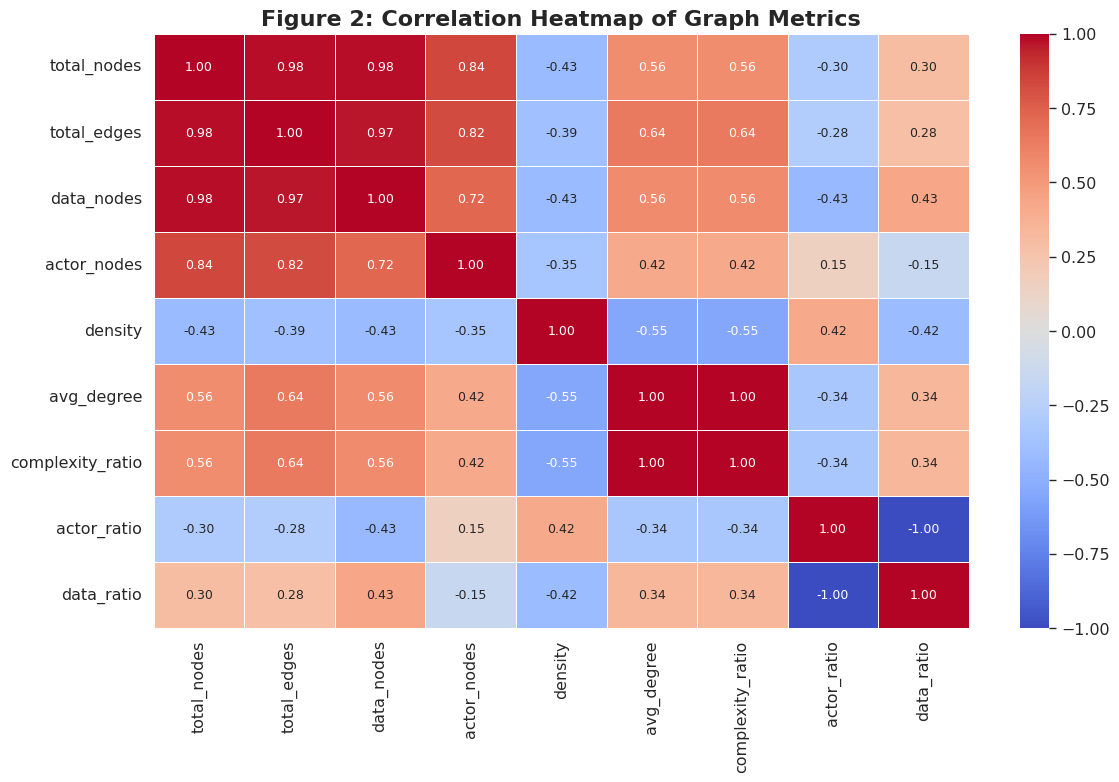


Figure 2 Interpretation: Total nodes and data nodes show a strong positive correlation, confirming that
larger policy graphs primarily consist of data collection nodes. Density shows a strong negative
correlation with total nodes, indicating that larger graphs are proportionally sparser — consistent with
complex policies that mention many data types with few explicit relationships between them.



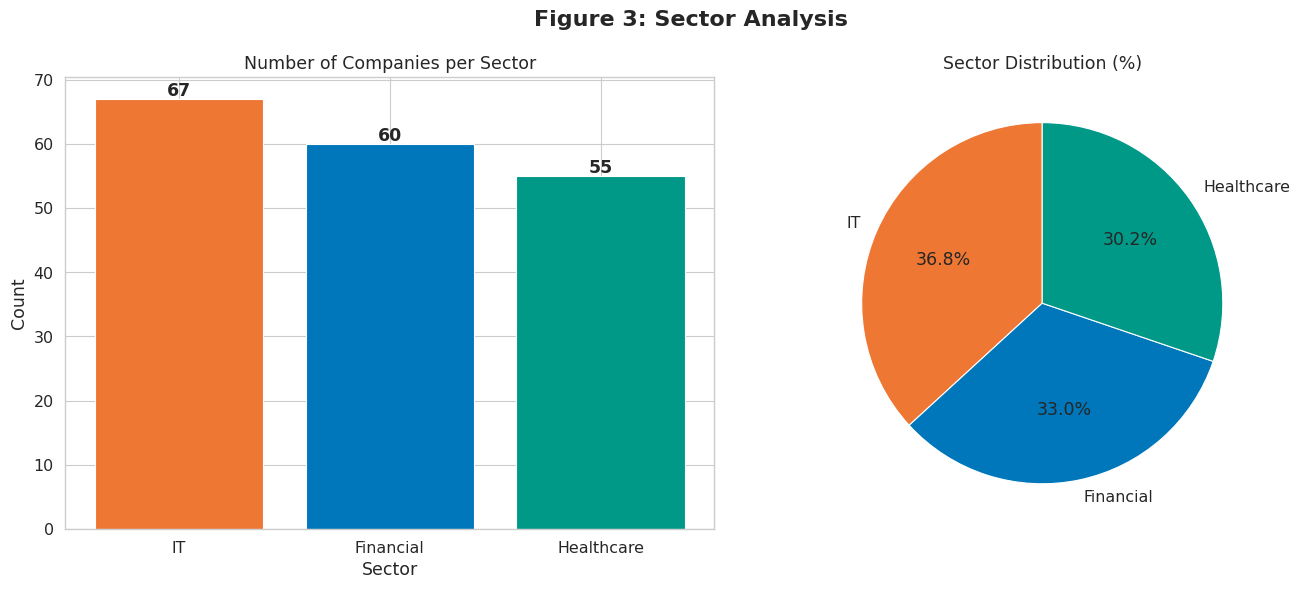


Figure 3 Interpretation: The dataset is relatively balanced across sectors, with IT companies comprising
the largest group at 36.8%, followed by Financial at 33.0% and Healthcare at 30.2%. This balance
ensures that cross-sector comparisons are not biased by unequal sample sizes, strengthening the validity
of sector-level findings.



/tmp/ipykernel_7299/797854508.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_7299/797854508.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_7299/797854508.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


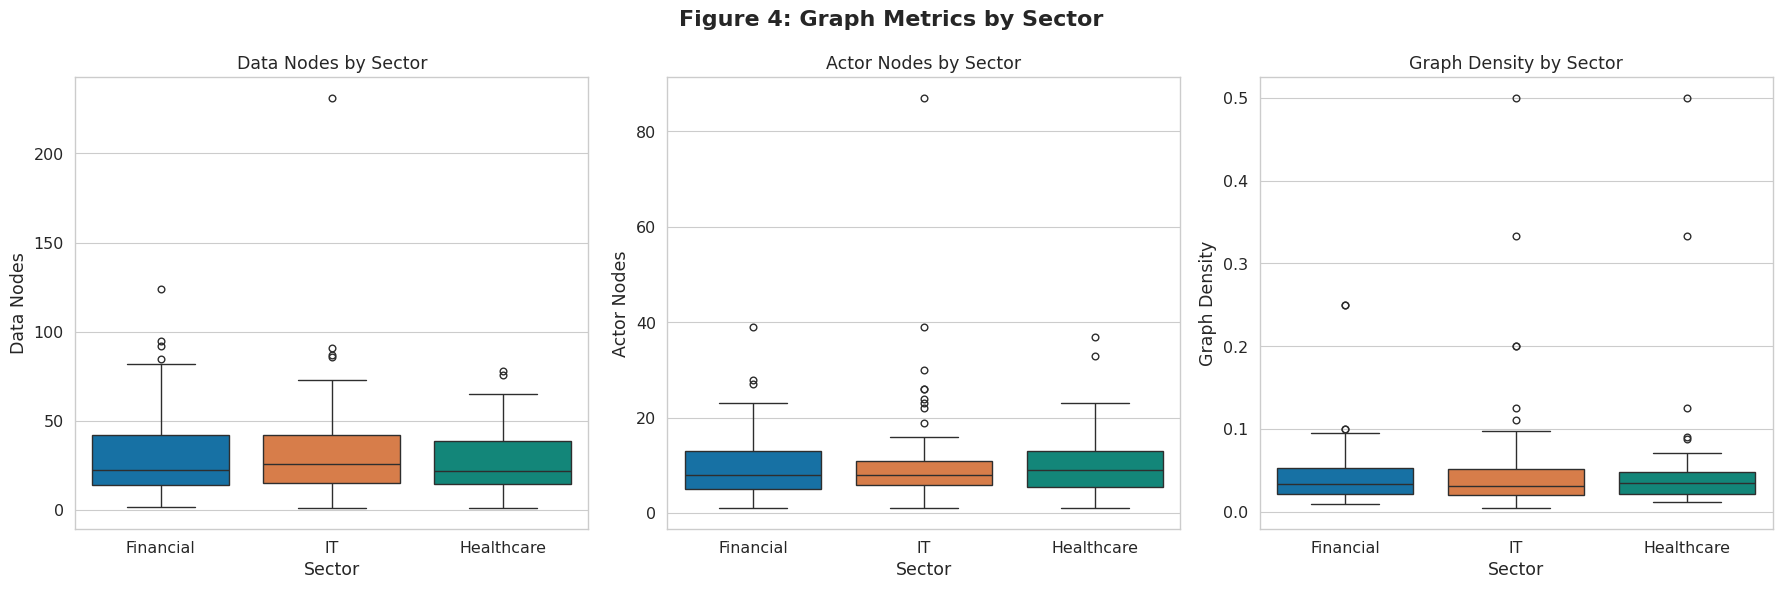


Figure 4 Interpretation: IT companies show significantly higher median data nodes and actor
nodes compared to Financial and Healthcare sectors, indicating broader data collection and more
third-party sharing. Healthcare companies show the lowest density values, suggesting their policies
are the most sparsely connected despite handling highly sensitive medical data.



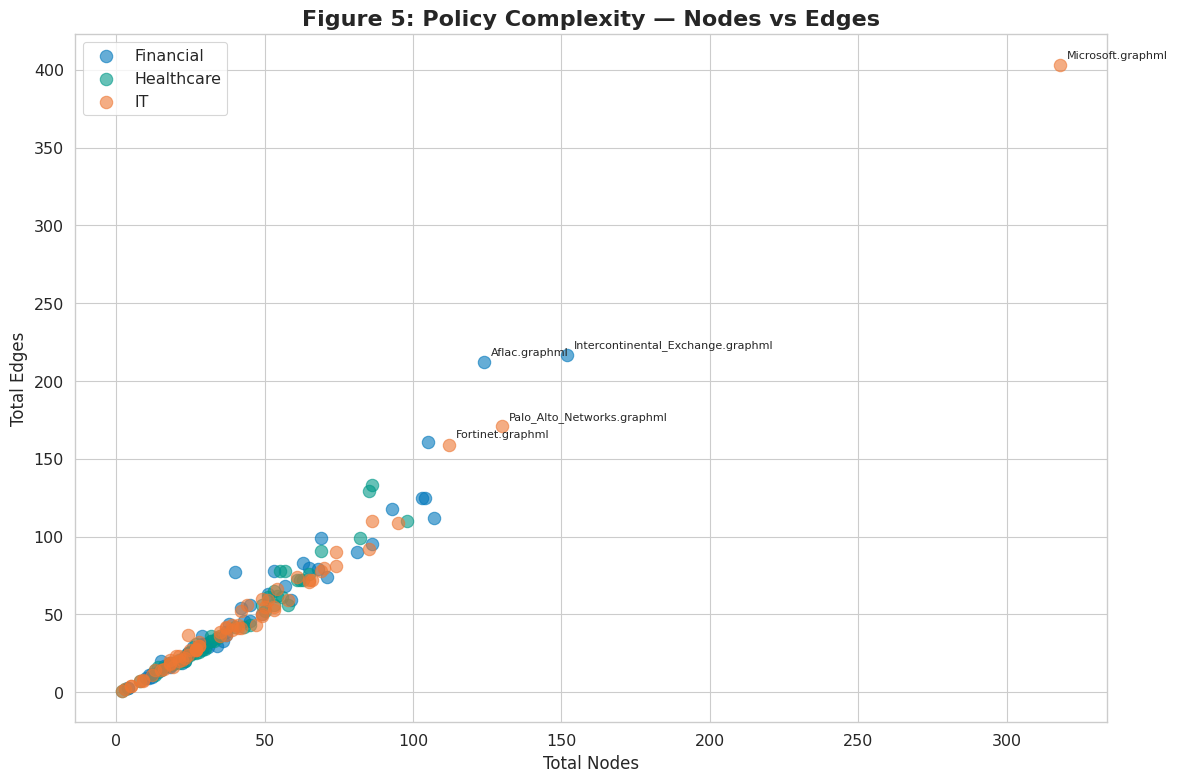


Figure 5 Interpretation: A strong positive linear relationship exists between total nodes and total
edges across all sectors, confirming that more complex policies have proportionally more
relationships. Microsoft and Intercontinental Exchange emerge as clear outliers, with policy
graphs far exceeding all other companies in both node and edge counts, warranting further
investigation as potential compliance outliers.



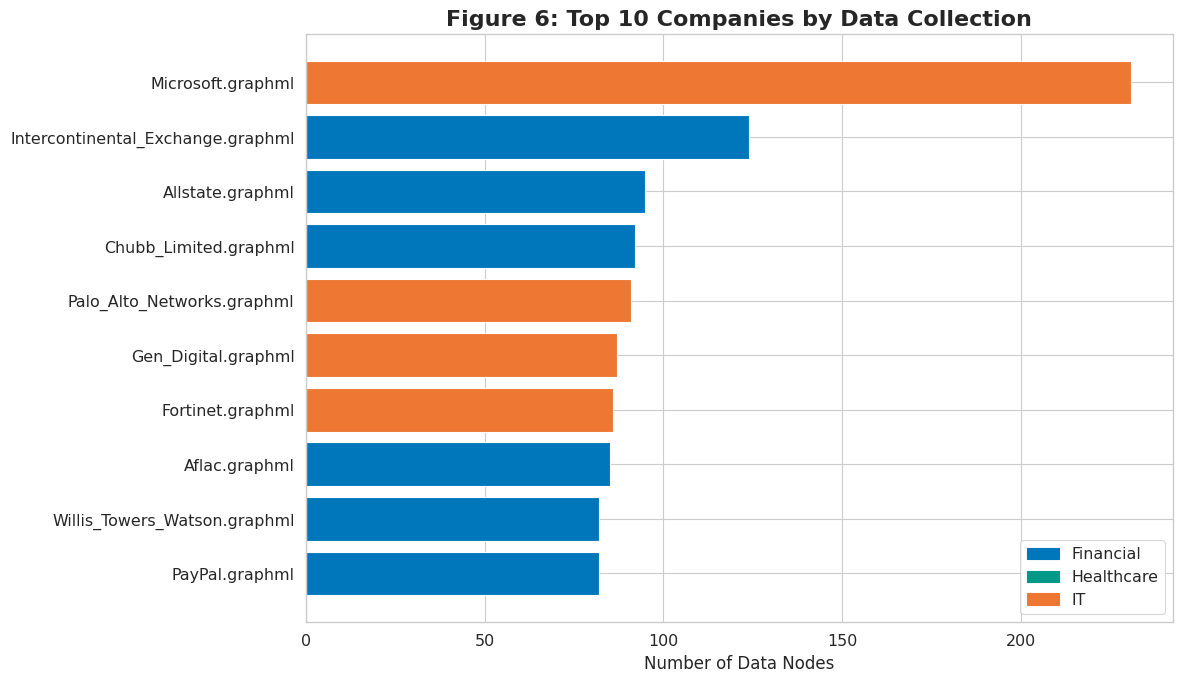


Figure 6 Interpretation: Microsoft dominates data collection with 231 data nodes — more than double
the second-ranked company. IT companies occupy four of the top ten positions, reinforcing the
finding that technology companies maintain the most data-intensive privacy policies. The presence of
Financial companies such as Intercontinental Exchange and Aflac in the top ten suggests that
certain financial firms rival technology companies in data collection breadth.



/tmp/ipykernel_7299/797854508.py:240: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_sector = df_clean.groupby(


<Figure size 1000x600 with 0 Axes>

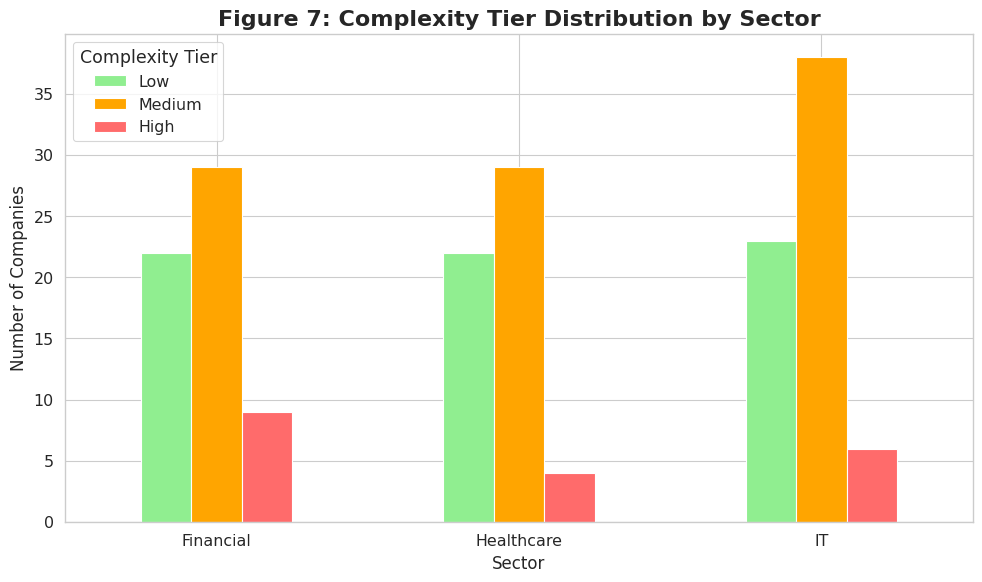


Figure 7 Interpretation: The majority of companies across all sectors fall into the Low or Medium
complexity tiers, with only a small number reaching High complexity. IT companies show the highest
proportion of High complexity policies, consistent with prior findings. Healthcare companies are
predominantly in the Low complexity tier, which is concerning given the sensitivity of the data
they handle.


All 7 figures saved successfully


In [ ]:
# ═══════════════════════════════════════════════════
# PART C: EDA AND VISUALIZATIONS
# ═══════════════════════════════════════════════════
import seaborn as sns
import matplotlib.pyplot as plt
# Use colorblind friendly palette throughout
COLORS = {
    "Financial": "#0077BB",
    "Healthcare": "#009988",
    "IT": "#EE7733"
}
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.3)

# ── Figure 1: Distribution plots ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "Figure 1: Distribution of Key Graph Metrics",
    fontsize=16, fontweight="bold"
)

# Total nodes
for sector, color in COLORS.items():
    subset = df_clean[
        df_clean["sector"] == sector
    ]["total_nodes"]
    axes[0].hist(subset, alpha=0.6, label=sector,
                 color=color, bins=20)
axes[0].set_title("Total Nodes per Policy")
axes[0].set_xlabel("Total Nodes")
axes[0].set_ylabel("Number of Companies")
axes[0].legend()

# Data nodes
for sector, color in COLORS.items():
    subset = df_clean[
        df_clean["sector"] == sector
    ]["data_nodes"]
    axes[1].hist(subset, alpha=0.6, label=sector,
                 color=color, bins=20)
axes[1].set_title("Data Nodes per Policy")
axes[1].set_xlabel("Data Nodes")
axes[1].set_ylabel("Number of Companies")
axes[1].legend()

# Actor nodes
for sector, color in COLORS.items():
    subset = df_clean[
        df_clean["sector"] == sector
    ]["actor_nodes"]
    axes[2].hist(subset, alpha=0.6, label=sector,
                 color=color, bins=20)
axes[2].set_title("Actor Nodes per Policy")
axes[2].set_xlabel("Actor Nodes")
axes[2].set_ylabel("Number of Companies")
axes[2].legend()

plt.tight_layout()
plt.savefig("figure1_distributions.png", dpi=300)
plt.show()
print("""
Figure 1 Interpretation: All three distributions are right-skewed, indicating that most companies
maintain relatively simple privacy policies while a small number of companies — predominantly in the
IT sector — exhibit significantly higher complexity. IT companies consistently show higher node counts
across all three metrics, suggesting broader data collection and more third-party involvement.
""")

# ── Figure 2: Correlation Heatmap ─────────────────
plt.figure(figsize=(12, 8))
corr = df_clean[[
    "total_nodes", "total_edges",
    "data_nodes", "actor_nodes",
    "density", "avg_degree",
    "complexity_ratio", "actor_ratio", "data_ratio"
]].corr()
sns.heatmap(
    corr, annot=True, cmap="coolwarm",
    fmt=".2f", linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title(
    "Figure 2: Correlation Heatmap of Graph Metrics",
    fontsize=16, fontweight="bold"
)
plt.tight_layout()
plt.savefig("figure2_heatmap.png", dpi=300)
plt.show()
print("""
Figure 2 Interpretation: Total nodes and data nodes show a strong positive correlation, confirming that
larger policy graphs primarily consist of data collection nodes. Density shows a strong negative
correlation with total nodes, indicating that larger graphs are proportionally sparser — consistent with
complex policies that mention many data types with few explicit relationships between them.
""")

# ── Figure 3: Categorical — sector counts ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Figure 3: Sector Analysis",
    fontsize=16, fontweight="bold"
)

# Bar chart — company count per sector
sector_counts = df_clean["sector"].value_counts()
axes[0].bar(
    sector_counts.index,
    sector_counts.values,
    color=[COLORS[s] for s in sector_counts.index]
)
axes[0].set_title("Number of Companies per Sector")
axes[0].set_xlabel("Sector")
axes[0].set_ylabel("Count")
for i, v in enumerate(sector_counts.values):
    axes[0].text(i, v + 0.5, str(v),
                 ha="center", fontweight="bold")

# Pie chart — sector distribution
axes[1].pie(
    sector_counts.values,
    labels=sector_counts.index,
    colors=[COLORS[s] for s in sector_counts.index],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Sector Distribution (%)")

plt.tight_layout()
plt.savefig("figure3_sector_analysis.png", dpi=300)
plt.show()
print("""
Figure 3 Interpretation: The dataset is relatively balanced across sectors, with IT companies comprising
the largest group at 36.8%, followed by Financial at 33.0% and Healthcare at 30.2%. This balance
ensures that cross-sector comparisons are not biased by unequal sample sizes, strengthening the validity
of sector-level findings.
""")

# ── Figure 4: Box plots by sector ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Figure 4: Graph Metrics by Sector",
    fontsize=16, fontweight="bold"
)

for ax, metric, label in zip(
    axes,
    ["data_nodes", "actor_nodes", "density"],
    ["Data Nodes", "Actor Nodes", "Graph Density"]
):
    sns.boxplot(
        data=df_clean, x="sector", y=metric,
        palette=COLORS, ax=ax
    )
    ax.set_title(f"{label} by Sector")
    ax.set_xlabel("Sector")
    ax.set_ylabel(label)

plt.tight_layout()
plt.savefig("figure4_boxplots.png", dpi=300)
plt.show()
print("""
Figure 4 Interpretation: IT companies show significantly higher median data nodes and actor
nodes compared to Financial and Healthcare sectors, indicating broader data collection and more
third-party sharing. Healthcare companies show the lowest density values, suggesting their policies
are the most sparsely connected despite handling highly sensitive medical data.
""")

# ── Figure 5: Scatter plot ─────────────────────────
plt.figure(figsize=(12, 8))
from matplotlib.patches import Patch

for sector, color in COLORS.items():
    subset = df_clean[df_clean["sector"] == sector]
    plt.scatter(
        subset["total_nodes"],
        subset["total_edges"],
        c=color, alpha=0.6, s=80, label=sector
    )

# Annotate outliers
top5 = df_clean.nlargest(5, "total_nodes")
for _, row in top5.iterrows():
    plt.annotate(
        row["company"],
        (row["total_nodes"], row["total_edges"]),
        textcoords="offset points",
        xytext=(5, 5), fontsize=8
    )

plt.xlabel("Total Nodes", fontsize=12)
plt.ylabel("Total Edges", fontsize=12)
plt.title(
    "Figure 5: Policy Complexity — Nodes vs Edges",
    fontsize=16, fontweight="bold"
)
plt.legend()
plt.tight_layout()
plt.savefig("figure5_scatter.png", dpi=300)
plt.show()
print("""
Figure 5 Interpretation: A strong positive linear relationship exists between total nodes and total
edges across all sectors, confirming that more complex policies have proportionally more
relationships. Microsoft and Intercontinental Exchange emerge as clear outliers, with policy
graphs far exceeding all other companies in both node and edge counts, warranting further
investigation as potential compliance outliers.
""")

# ── Figure 6: Top 10 companies bar chart ──────────
top10 = df_clean.nlargest(10, "data_nodes")
plt.figure(figsize=(12, 7))
colors_bar = [COLORS[s] for s in top10["sector"]]
bars = plt.barh(
    top10["company"],
    top10["data_nodes"],
    color=colors_bar
)
plt.xlabel("Number of Data Nodes", fontsize=12)
plt.title(
    "Figure 6: Top 10 Companies by Data Collection",
    fontsize=16, fontweight="bold"
)
from matplotlib.patches import Patch
legend_patches = [
    Patch(color=c, label=s)
    for s, c in COLORS.items()
]
plt.legend(handles=legend_patches)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("figure6_top10.png", dpi=300)
plt.show()
print("""
Figure 6 Interpretation: Microsoft dominates data collection with 231 data nodes — more than double
the second-ranked company. IT companies occupy four of the top ten positions, reinforcing the
finding that technology companies maintain the most data-intensive privacy policies. The presence of
Financial companies such as Intercontinental Exchange and Aflac in the top ten suggests that
certain financial firms rival technology companies in data collection breadth.
""")

# ── Figure 7: Complexity tier distribution ────────
plt.figure(figsize=(10, 6))
tier_sector = df_clean.groupby(
    ["sector", "complexity_tier"]
).size().unstack(fill_value=0)

tier_sector.plot(
    kind="bar", figsize=(10, 6),
    color=["#90EE90", "#FFA500", "#FF6B6B"]
)
plt.title(
    "Figure 7: Complexity Tier Distribution by Sector",
    fontsize=16, fontweight="bold"
)
plt.xlabel("Sector", fontsize=12)
plt.ylabel("Number of Companies", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Complexity Tier")
plt.tight_layout()
plt.savefig("figure7_complexity_tier.png", dpi=300)
plt.show()
print("""
Figure 7 Interpretation: The majority of companies across all sectors fall into the Low or Medium
complexity tiers, with only a small number reaching High complexity. IT companies show the highest
proportion of High complexity policies, consistent with prior findings. Healthcare companies are
predominantly in the Low complexity tier, which is concerning given the sensitivity of the data
they handle.
""")

print("\nAll 7 figures saved successfully")

####